# Apply mode choice

Apply mode choice model to the same estimation file so we can test whether it produces reasonable results.

Use the original winner, but try calibrating a downtown constant

It is set by trial and error using by setting ASC_TNC_DOWNTOWN, and then adjusting the transit and walk ASCs to match the total shares

In [1]:
import numpy as np

import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.reset_option('display.float_format')

In [2]:
# read the data
df = pd.read_csv('out/combined_estimation_file.csv')
df.head()

C:\Users\ger225\AppData\Local\Temp\ipykernel_28844\360866534.py:2: DtypeWarning: Columns (0: depart_date, 1: linked_trip_mode_labeled, 2: income_labeled) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('out/combined_estimation_file.csv')


,Unnamed: 0,hh_id,person_id,person_num,day_id,day_num,depart_date,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,linked_trip_mode_labeled,mode,mode2,distance_miles,duration_minutes,o_district,d_district,o_community,d_community,time_period,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,income_broad,income_labeled,hh_share_inc_under_100k,hh_share_inc_over_100k,hh_share_inc_under_100k_dropoff,hh_share_inc_over_100k_dropoff,tnc_trip_id,obs_fare,obs_tip,obs_additional_charges,transit_avail,walk_avail,transit_or_walk_avail,tnc_time_2,tnc_fare_2,time_period_num,avg_obs_tnc_time,avg_obs_tnc_fare,tnc_observed,tnc_time_3,tnc_fare_3,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk
0,0,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031081500,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.810270,20.0,Downtown,Downtown,32.0,8.0,midday,3.738333,6.186942,5,11.186942,6.707731,2.5,16.205401,22.0,16.205401,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,0.321678,0.678322,NaN,NaN,NaN,NaN,1,1,1,11.186942,6.707731,3,NaN,NaN,False,11.186942,6.707731,-5.018459,6.707731
1,1,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081500,17031081403,2.400012e+15,2.0,15.0,1853.792592,Walk,walk,walk,0.338027,28.0,Downtown,Downtown,8.0,8.0,midday,1.660000,2.747300,5,7.747300,4.798943,2.5,6.760535,7.0,6.760535,True,0.0,5.0,"$150,000 or more",0.321678,0.678322,0.460539,0.539461,NaN,NaN,NaN,NaN,1,1,1,7.747300,4.798943,3,7.157143,9.642857,True,12.157143,9.642857,5.396607,9.642857
2,2,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081403,17031320101,2.400012e+15,3.0,15.0,1853.792592,Walk,walk,walk,0.549293,15.0,Downtown,Downtown,8.0,32.0,midday,3.421667,5.662858,5,10.662858,6.244886,2.5,10.985870,23.0,10.985870,True,0.0,5.0,"$150,000 or more",0.460539,0.539461,0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,1,10.662858,6.244886,3,NaN,NaN,False,10.662858,6.244886,-0.323012,6.244886
3,3,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320101,2.400012e+15,4.0,15.0,1853.792592,Walk,walk,walk,0.319386,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.167457,2.5,6.387712,12.0,6.387712,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,1,8.643758,5.167457,3,NaN,NaN,False,8.643758,5.167457,2.256047,5.167457
4,4,24000124.0,2.400012e+09,2.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320102,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.751861,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.561010,2.5,15.037220,12.0,12.000000,False,2.5,5.0,"$150,000 or more",0.341000,0.659000,0.519520,0.480480,NaN,NaN,NaN,NaN,1,1,1,8.643758,5.561010,3,NaN,NaN,False,8.643758,5.561010,-3.356242,3.061010


In [3]:
# drop recrods where we don't know the income shares

trips_before = len(df)

df = df[df['hh_share_inc_under_100k']>0]
df = df[df['hh_share_inc_under_100k']>0]

print("Before: " + str(trips_before) + " After: " + str(len(df)))

Before: 161249 After: 161105


In [4]:
# we will apply this using a single VOT for each record, so select the trip's income level from the zone's. 

rng = np.random.default_rng(42)
df['random'] = rng.random(len(df))

df['imputed_income_under_100k'] = np.where(df['random']<df['hh_share_inc_under_100k'], 1, 0)
df['imputed_income_over_100k'] = 1 - df['imputed_income_under_100k']

df.head()

,Unnamed: 0,hh_id,person_id,person_num,day_id,day_num,depart_date,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,linked_trip_mode_labeled,mode,mode2,distance_miles,duration_minutes,o_district,d_district,o_community,d_community,time_period,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,income_broad,income_labeled,hh_share_inc_under_100k,hh_share_inc_over_100k,hh_share_inc_under_100k_dropoff,hh_share_inc_over_100k_dropoff,tnc_trip_id,obs_fare,obs_tip,obs_additional_charges,transit_avail,walk_avail,transit_or_walk_avail,tnc_time_2,tnc_fare_2,time_period_num,avg_obs_tnc_time,avg_obs_tnc_fare,tnc_observed,tnc_time_3,tnc_fare_3,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk,random,imputed_income_under_100k,imputed_income_over_100k
0,0,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031081500,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.810270,20.0,Downtown,Downtown,32.0,8.0,midday,3.738333,6.186942,5,11.186942,6.707731,2.5,16.205401,22.0,16.205401,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,0.321678,0.678322,NaN,NaN,NaN,NaN,1,1,1,11.186942,6.707731,3,NaN,NaN,False,11.186942,6.707731,-5.018459,6.707731,0.773956,0,1
1,1,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081500,17031081403,2.400012e+15,2.0,15.0,1853.792592,Walk,walk,walk,0.338027,28.0,Downtown,Downtown,8.0,8.0,midday,1.660000,2.747300,5,7.747300,4.798943,2.5,6.760535,7.0,6.760535,True,0.0,5.0,"$150,000 or more",0.321678,0.678322,0.460539,0.539461,NaN,NaN,NaN,NaN,1,1,1,7.747300,4.798943,3,7.157143,9.642857,True,12.157143,9.642857,5.396607,9.642857,0.438878,0,1
2,2,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081403,17031320101,2.400012e+15,3.0,15.0,1853.792592,Walk,walk,walk,0.549293,15.0,Downtown,Downtown,8.0,32.0,midday,3.421667,5.662858,5,10.662858,6.244886,2.5,10.985870,23.0,10.985870,True,0.0,5.0,"$150,000 or more",0.460539,0.539461,0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,1,10.662858,6.244886,3,NaN,NaN,False,10.662858,6.244886,-0.323012,6.244886,0.858598,0,1
3,3,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320101,2.400012e+15,4.0,15.0,1853.792592,Walk,walk,walk,0.319386,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.167457,2.5,6.387712,12.0,6.387712,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,1,8.643758,5.167457,3,NaN,NaN,False,8.643758,5.167457,2.256047,5.167457,0.697368,0,1
4,4,24000124.0,2.400012e+09,2.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320102,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.751861,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.561010,2.5,15.037220,12.0,12.000000,False,2.5,5.0,"$150,000 or more",0.341000,0.659000,0.519520,0.480480,NaN,NaN,NaN,NaN,1,1,1,8.643758,5.561010,3,NaN,NaN,False,8.643758,5.561010,-3.356242,3.061010,0.094177,1,0


In [5]:
# define a flag for the origin and destination downtown

df['o_downtown'] = np.where(df['o_district']=='Downtown', 1, 0)
df['d_downtown'] = np.where(df['d_district']=='Downtown', 1, 0)

In [6]:
# update modal availability

# transit must be less than 2 hours
df['transit_avail'] = np.where(df['transit_time']<120, 1, 0)

# walk must be less than 30 minutes
df['walk_avail'] = np.where(df['walk_time']<30, 1, 0)

# drop trips that choose an unavailable alternative
trips_before = len(df)
df = df[(df['transit_avail']==1) | (df['mode']!='transit')].copy()
df = df[(df['walk_avail']==1) | (df['mode']!='walk')].copy()

print("Before: " + str(trips_before) + " After: " + str(len(df)))

Before: 161105 After: 160922


Our preferred model is this

    Results for model mnl_mode_choice
    Nbr of parameters:		5
    Sample size:			160922
    Excluded data:			0
    Null log likelihood:		-118890.3
    Final log likelihood:		-64088.56
    Likelihood ratio test (null):		109603.4
    Rho square (null):			0.461
    Rho bar square (null):			0.461
    Akaike Information Criterion:	128187.1
    Bayesian Information Criterion:	128237.1

                    Value  Rob. Std err  Rob. t-test  Rob. p-value
    ASC_TRANSIT  1.706218      0.025159    67.818318           0.0
    ASC_WALK     3.520884      0.028358   124.156244           0.0
    B_COST_HI   -0.039199      0.003356   -11.680922           0.0
    B_COST_LOW  -0.077109      0.003006   -25.651117           0.0
    B_TIME      -0.021315      0.000657   -32.428708           0.0

    Value of Time for HH <$100k: 16.59
    Value of Time for HH $100k+: 32.63

In [7]:
# calculate utilities and apply mode choice
ASC_TRANSIT =  1.824339        # before calibration: 1.706218
ASC_WALK    =  3.662597        # before calibration: 3.520884
B_COST_HI   = -0.039199 
B_COST_LOW  = -0.077109 
B_TIME      = -0.021315 
ASC_TNC_DOWNTOWN = 0.9         # before calibration: 0

# utility equations
df['util_tnc']     =               B_TIME * df['tnc_time_3']   + B_COST_LOW * df['tnc_fare_3'] * df['imputed_income_under_100k']   + B_COST_HI * df['tnc_fare_3'] * df['imputed_income_over_100k']   + ASC_TNC_DOWNTOWN * df['o_downtown'] * df['d_downtown']
df['util_transit'] = ASC_TRANSIT + B_TIME * df['transit_time'] + B_COST_LOW * df['transit_fare'] * df['imputed_income_under_100k'] + B_COST_HI * df['transit_fare'] * df['imputed_income_over_100k']
df['util_walk']    = ASC_WALK    + B_TIME * df['walk_time']

# exponentiated utilities with restricted availability by mode
df['exp_util_tnc']     = np.exp(df['util_tnc'])
df['exp_util_transit'] = np.exp(df['util_transit']) * df['transit_avail']
df['exp_util_walk']    = np.exp(df['util_walk'])    * df['walk_avail']
df['exp_util_total'] = df['exp_util_tnc'] + df['exp_util_transit'] + df['exp_util_walk'] 

# modeled mode shares
df['share_tnc']     = df['exp_util_tnc']     / df['exp_util_total'] 
df['share_transit'] = df['exp_util_transit'] / df['exp_util_total'] 
df['share_walk']    = df['exp_util_walk']    / df['exp_util_total'] 
df['share_total']   = df['share_tnc'] + df['share_transit'] + df['share_walk']


In [8]:
df.head()

,Unnamed: 0,hh_id,person_id,person_num,day_id,day_num,depart_date,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,linked_trip_mode_labeled,mode,mode2,distance_miles,duration_minutes,o_district,d_district,o_community,d_community,time_period,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,income_broad,income_labeled,hh_share_inc_under_100k,hh_share_inc_over_100k,hh_share_inc_under_100k_dropoff,hh_share_inc_over_100k_dropoff,tnc_trip_id,obs_fare,obs_tip,obs_additional_charges,transit_avail,walk_avail,transit_or_walk_avail,tnc_time_2,tnc_fare_2,time_period_num,avg_obs_tnc_time,avg_obs_tnc_fare,tnc_observed,tnc_time_3,tnc_fare_3,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk,random,imputed_income_under_100k,imputed_income_over_100k,o_downtown,d_downtown,util_tnc,util_transit,util_walk,exp_util_tnc,exp_util_transit,exp_util_walk,exp_util_total,share_tnc,share_transit,share_walk,share_total
0,0,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031081500,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.810270,20.0,Downtown,Downtown,32.0,8.0,midday,3.738333,6.186942,5,11.186942,6.707731,2.5,16.205401,22.0,16.205401,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,0.321678,0.678322,NaN,NaN,NaN,NaN,1,1,1,11.186942,6.707731,3,NaN,NaN,False,11.186942,6.707731,-5.018459,6.707731,0.773956,0,1,1,1,0.398614,1.257411,3.317179,1.489758,3.516308,27.582427,32.588494,0.045714,0.107900,0.846385,1.0
1,1,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081500,17031081403,2.400012e+15,2.0,15.0,1853.792592,Walk,walk,walk,0.338027,28.0,Downtown,Downtown,8.0,8.0,midday,1.660000,2.747300,5,7.747300,4.798943,2.5,6.760535,7.0,6.760535,True,0.0,5.0,"$150,000 or more",0.321678,0.678322,0.460539,0.539461,NaN,NaN,NaN,NaN,1,1,1,7.747300,4.798943,3,7.157143,9.642857,True,12.157143,9.642857,5.396607,9.642857,0.438878,0,1,1,1,0.262880,1.577136,3.518496,1.300671,4.841074,33.733661,39.875406,0.032618,0.121405,0.845977,1.0
2,2,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031081403,17031320101,2.400012e+15,3.0,15.0,1853.792592,Walk,walk,walk,0.549293,15.0,Downtown,Downtown,8.0,32.0,midday,3.421667,5.662858,5,10.662858,6.244886,2.5,10.985870,23.0,10.985870,True,0.0,5.0,"$150,000 or more",0.460539,0.539461,0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,1,10.662858,6.244886,3,NaN,NaN,False,10.662858,6.244886,-0.323012,6.244886,0.858598,0,1,1,1,0.427928,1.236096,3.428433,1.534075,3.442151,30.828303,35.804529,0.042846,0.096137,0.861017,1.0
3,3,24000124.0,2.400012e+09,1.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320101,2.400012e+15,4.0,15.0,1853.792592,Walk,walk,walk,0.319386,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.167457,2.5,6.387712,12.0,6.387712,True,0.0,5.0,"$150,000 or more",0.341000,0.659000,0.341000,0.659000,NaN,NaN,NaN,NaN,1,1,1,8.643758,5.167457,3,NaN,NaN,False,8.643758,5.167457,2.256047,5.167457,0.697368,0,1,1,1,0.513199,1.470562,3.526443,1.670627,4.351678,34.002802,40.025107,0.041739,0.108724,0.849537,1.0
4,4,24000124.0,2.400012e+09,2.0,2.400012e+11,1.0,2024-05-21,17031320101,17031320102,2.400012e+15,1.0,15.0,1853.792592,Walk,walk,walk,0.751861,16.0,Downtown,Downtown,32.0,32.0,midday,2.201667,3.643758,5,8.643758,5.561010,2.5,15.037220,12.0,12.000000,False,2.5,5.0,"$150,000 or more",0.341000,0.659000,0.519520,0.480480,NaN,NaN,NaN,NaN,1,1,1,8.643758,5.561010,3,NaN,NaN,False,8.643758,5.561010,-3.356242,3.061010,0.094177,1,0,1,1,0.286954,1.375787,3.342079,1.332363,3.958189,28.277845,33.568397,0.039691,0.117914,0.842395,1.0


In [9]:
df.tail()

,Unnamed: 0,hh_id,person_id,person_num,day_id,day_num,depart_date,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,linked_trip_mode_labeled,mode,mode2,distance_miles,duration_minutes,o_district,d_district,o_community,d_community,time_period,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,income_broad,income_labeled,hh_share_inc_under_100k,hh_share_inc_over_100k,hh_share_inc_under_100k_dropoff,hh_share_inc_over_100k_dropoff,tnc_trip_id,obs_fare,obs_tip,obs_additional_charges,transit_avail,walk_avail,transit_or_walk_avail,tnc_time_2,tnc_fare_2,time_period_num,avg_obs_tnc_time,avg_obs_tnc_fare,tnc_observed,tnc_time_3,tnc_fare_3,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk,random,imputed_income_under_100k,imputed_income_over_100k,o_downtown,d_downtown,util_tnc,util_transit,util_walk,exp_util_tnc,exp_util_transit,exp_util_walk,exp_util_total,share_tnc,share_transit,share_walk,share_total
161244,161244,NaN,NaN,NaN,NaN,NaN,NaN,17031839000,17031071600,NaN,NaN,NaN,1.0,NaN,tnc,tnc,3.4,10.116667,Downtown,Other,32.0,7.0,night,8.488333,10.107907,5,15.107907,10.771317,2.5,68.0,95.0,95.0,False,2.5,NaN,NaN,0.485000,0.515000,0.266266,0.733734,19d5bdd87861afc50be6e60d86bb6162eab1d37f,27.5,0.0,3.55,1,0,1,15.116667,27.5,1,10.116667,27.5,True,15.116667,27.5,-79.883333,25.0,0.360388,1,0,1,0,-2.442709,-0.393359,2.213177,0.086925,0.674787,0.0,0.761712,0.114118,0.885882,0.0,1.0
161245,161245,NaN,NaN,NaN,NaN,NaN,NaN,17031831500,17031190100,NaN,NaN,NaN,1.0,NaN,tnc,tnc,2.3,10.783333,Other,Other,19.0,19.0,night,8.048333,9.583955,5,14.583955,10.063092,2.5,46.0,74.0,74.0,False,2.5,NaN,NaN,0.567000,0.433000,0.775551,0.224449,19e320f52f745a31fb9e936bb81054ff717a18f9,5.0,0.0,1.45,1,0,1,15.783333,5.0,1,10.040000,9.5,True,15.783333,5.0,-58.216667,2.5,0.520060,1,0,0,0,-0.721967,0.054256,2.682107,0.485796,1.055755,0.0,1.541551,0.315134,0.684866,0.0,1.0
161246,161246,NaN,NaN,NaN,NaN,NaN,NaN,17031330101,17031430200,NaN,NaN,NaN,1.0,NaN,tnc,tnc,8.5,15.766667,Tourist,Other,33.0,43.0,night,13.246667,15.774131,5,20.774131,17.835923,2.5,170.0,999.0,999.0,False,2.5,NaN,NaN,0.197605,0.802395,0.816000,0.184000,1a450fa5be8973044470459fb0996f917539193c,15.0,0.0,3.63,0,0,0,20.766667,15.0,1,15.766667,15.0,True,20.766667,15.0,-978.233333,12.5,0.673234,0,1,0,0,-1.030626,-19.567344,0.039047,0.356783,0.000000,0.0,0.356783,1.000000,0.000000,0.0,1.0
161247,161247,NaN,NaN,NaN,NaN,NaN,NaN,17031460400,17031710600,NaN,NaN,NaN,1.0,NaN,tnc,tnc,5.4,19.316667,Other,Other,46.0,71.0,night,11.526667,13.725955,5,18.725955,16.562925,2.5,108.0,147.0,147.0,False,2.5,NaN,NaN,0.715431,0.284569,0.875250,0.124750,1acd6586d7fa041e6f6ba72c92ce334848422db5,15.0,0.0,1.23,0,0,1,24.316667,15.0,1,19.316667,15.0,True,24.316667,15.0,-122.683333,12.5,0.199424,1,0,0,0,-1.674945,-1.501739,1.360577,0.187319,0.000000,0.0,0.187319,1.000000,0.000000,0.0,1.0
161248,161248,NaN,NaN,NaN,NaN,NaN,NaN,17031570500,17031840100,NaN,NaN,NaN,1.0,NaN,tnc,tnc,5.1,16.983333,Other,Other,57.0,60.0,night,11.460000,13.646568,5,18.646568,15.281805,2.5,102.0,165.0,165.0,False,2.5,NaN,NaN,0.655345,0.344655,0.602603,0.397397,1b007e2eac690d6a97a342a235d311208a15022c,12.5,0.0,4.11,0,0,1,21.983333,12.5,1,16.983333,12.5,True,21.983333,12.5,-143.016667,10.0,0.056713,1,0,0,0,-1.432437,-1.885409,1.488467,0.238726,0.000000,0.0,0.238726,1.000000,0.000000,0.0,1.0


In [10]:
# calculate the modeled weighted trips, and compare to the observed

df['modeled_trips_tnc']     = df['linked_trip_weight'] * df['share_tnc']
df['modeled_trips_transit'] = df['linked_trip_weight'] * df['share_transit']
df['modeled_trips_walk']    = df['linked_trip_weight'] * df['share_walk']


In [11]:
# tabulate modeled trips (tnc, transit, walk) by observed mode

tab = df.groupby('mode')[['modeled_trips_tnc', 'modeled_trips_transit', 'modeled_trips_walk']].sum()
tab['modeled_trips_total'] = tab.sum(axis=1)
tab.loc['Total'] = tab.sum()
tab.style.format('{:,.0f}')


,modeled_trips_tnc,modeled_trips_transit,modeled_trips_walk,modeled_trips_total
mode,,,,
tnc,"27,838","100,709","27,460","156,006"
transit,"100,391","770,919","156,566","1,027,876"
walk,"29,115","155,631","1,303,213","1,487,959"
Total,"157,344","1,027,258","1,487,239","2,671,841"


In [12]:
# same tabulation as row percentages (share of each observed mode's trips)

tab_pct = tab.loc[:, ['modeled_trips_tnc', 'modeled_trips_transit', 'modeled_trips_walk']]
tab_pct = tab_pct.div(tab_pct.sum(axis=1), axis=0) * 100
tab_pct['total'] = tab_pct.sum(axis=1)
tab_pct.style.format('{:.1f}%')


,modeled_trips_tnc,modeled_trips_transit,modeled_trips_walk,total
mode,,,,
tnc,17.8%,64.6%,17.6%,100.0%
transit,9.8%,75.0%,15.2%,100.0%
walk,2.0%,10.5%,87.6%,100.0%
Total,5.9%,38.4%,55.7%,100.0%


It does quite well on the overall mode shares, but because TNC is a low-overall percentage, we are not especially likely to get it right. 

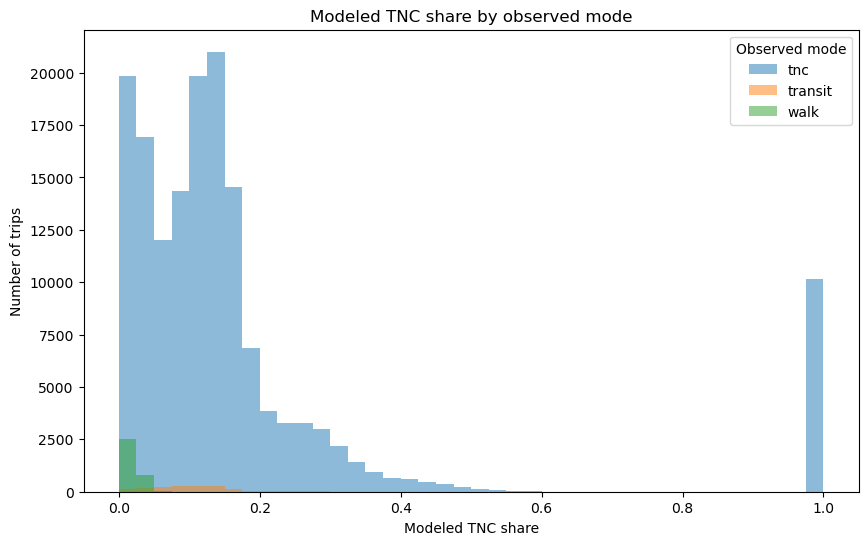

In [13]:
# histogram of modeled TNC share, color-coded by observed mode

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
bins = np.linspace(0, 1, 41)

for mode_name, grp in df.groupby('mode'):
    ax.hist(grp['share_tnc'], bins=bins, alpha=0.5, label=mode_name)

ax.set_xlabel('Modeled TNC share')
ax.set_ylabel('Number of trips')
ax.set_title('Modeled TNC share by observed mode')
ax.legend(title='Observed mode')
plt.show()


In [14]:
# compare by district to the observed
from IPython.display import display

df['obs_trips_tnc']     = df['linked_trip_weight'] * (df['mode'] == 'tnc')
df['obs_trips_transit'] = df['linked_trip_weight'] * (df['mode'] == 'transit')
df['obs_trips_walk']    = df['linked_trip_weight'] * (df['mode'] == 'walk')

modes = {
    'tnc':     ('obs_trips_tnc',     'modeled_trips_tnc'),
    'transit': ('obs_trips_transit', 'modeled_trips_transit'),
    'walk':    ('obs_trips_walk',    'modeled_trips_walk'),
}

for mode_name, (base_col, scen_col) in modes.items():
    base = df.pivot_table(index='o_district', columns='d_district', values=base_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    scen = df.pivot_table(index='o_district', columns='d_district', values=scen_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    pct = (scen - base) / base * 100

    print(f'\n===== {mode_name.upper()} =====')
    print('Observed:')
    display(base.style.format('{:,.0f}'))
    print('Modeled:')
    display(scen.style.format('{:,.0f}'))
    print('Percentage difference:')
    display(pct.style.format('{:+.1f}%'))



===== TNC =====
Observed:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"26,926","19,143",428,"46,497"
Other,"21,009","86,578",505,"108,092"
Tourist,514,899,4,"1,417"
Total,"48,449","106,620",937,"156,006"


Modeled:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"26,791","21,952",306,"49,048"
Other,"25,692","76,748",265,"102,705"
Tourist,349,"5,224",18,"5,590"
Total,"52,832","103,923",589,"157,344"


Percentage difference:


...

d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"325,346","34,567","3,833","363,746"
Other,"28,373","1,088,937",0,"1,117,310"
Tourist,"3,834","1,489","1,580","6,903"
Total,"357,553","1,124,994","5,412","1,487,959"


Modeled:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"340,961","36,076","3,461","380,498"
Other,"30,839","1,069,620",4,"1,100,463"
Tourist,"3,550","1,338","1,389","6,277"
Total,"375,351","1,107,033","4,855","1,487,239"


Percentage difference:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,+4.8%,+4.4%,-9.7%,+4.6%
Other,+8.7%,-1.8%,+inf%,-1.5%
Tourist,-7.4%,-10.2%,-12.1%,-9.1%
Total,+5.0%,-1.6%,-10.3%,-0.0%


Looking at the plot and the data, we observe that when share_tnc is 1, it is because neither transit nor walk are available.  These trips will become cheaper with pricing, but that change will not result in additional trips (because it is only the trade off between TNC and transit/walk).  

In cases where the share_tnc is close to zero, it occurs where either the observed travel time or the cost on TNC is  high.  We have about 966 TNC trips where the predicted mode share is less than 1%.  These are a small percentage of outliers.  These are cases where either walk/transit is quite good, or where the time/fare on TNC is high.  We always see that a small number of people choose something even though it looks like a bad choice from our (simplified) data.

# Run a scenario.

Run a pricing scenario to make sure it is reasonable.  Try the pricing scenario from Alex's work.  

    Table 1: 2020 Chicago Ground Transportation Tax Updated Fees
    RideType Surcharge 2019 Fee 2020 Fee Difference Percent Difference
    Single	    None	    $0.72	$1.25	$0.53	74%
    Shared	    None	    $0.72	$0.65	($0.07)	-10%
    Single	    Tourist	    $5.72	$6.25	$0.53	9%
    Shared	    Tourist	    $5.72	$5.65	($0.07)	-1%
    Single	    Downtown*       $0.72	$3.00	$2.28	317%
    Shared	    Downtown*       $0.72	$1.25	$0.53	74%
    Single 	    DT&Tourist	    $5.72	$8.00   $2.28	40%
    Shared	    DT&Tourist	    $5.72	$6.25	$0.53	9%
    * Downtown surcharge only charged from 6am to 10pm during weekdays


In [15]:
df['tnc_fare_scenario'] = df['tnc_fare_3'] + 0.53
df['tnc_fare_scenario'] = np.where(df['o_district']=='Downtown', df['tnc_fare_scenario'] + 2.28, df['tnc_fare_scenario'])
df['tnc_fare_scenario'] = np.where(df['d_district']=='Downtown', df['tnc_fare_scenario'] + 2.28, df['tnc_fare_scenario'])

In [16]:
# calculate utilities and apply mode choice

# utility equations
df['scen_util_tnc']     = B_TIME * df['tnc_time_3']   + B_COST_LOW * df['tnc_fare_scenario'] * df['imputed_income_under_100k']   + B_COST_HI * df['tnc_fare_scenario'] * df['imputed_income_over_100k'] + ASC_TNC_DOWNTOWN * df['o_downtown'] * df['d_downtown']

# exponentiated utilities with restricted availability by mode
df['scen_exp_util_tnc']     = np.exp(df['scen_util_tnc'])
df['scen_exp_util_total'] = df['scen_exp_util_tnc'] + df['exp_util_transit'] + df['exp_util_walk'] 

# modeled mode shares
df['scen_share_tnc']     = df['scen_exp_util_tnc'] / df['scen_exp_util_total'] 
df['scen_share_transit'] = df['exp_util_transit']  / df['scen_exp_util_total'] 
df['scen_share_walk']    = df['exp_util_walk']     / df['scen_exp_util_total'] 
df['scen_share_total']   = df['scen_share_tnc'] + df['scen_share_transit'] + df['scen_share_walk']

# calculate trips
df['scen_modeled_trips_tnc']     = df['linked_trip_weight'] * df['scen_share_tnc']
df['scen_modeled_trips_transit'] = df['linked_trip_weight'] * df['scen_share_transit']
df['scen_modeled_trips_walk']    = df['linked_trip_weight'] * df['scen_share_walk']


# Applied across all records (TNC + Survey) and tabulating modeled trips across all modes

This is just applying to our estimatino data set. 

In [17]:
# base vs scenario by mode, as o_district (rows) x d_district (cols) matrices with row/col totals
from IPython.display import display

modes = {
    'tnc':     ('modeled_trips_tnc',     'scen_modeled_trips_tnc'),
    'transit': ('modeled_trips_transit', 'scen_modeled_trips_transit'),
    'walk':    ('modeled_trips_walk',    'scen_modeled_trips_walk'),
}

for mode_name, (base_col, scen_col) in modes.items():
    base = df.pivot_table(index='o_district', columns='d_district', values=base_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    scen = df.pivot_table(index='o_district', columns='d_district', values=scen_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    pct = (scen - base) / base * 100

    print(f'\n===== {mode_name.upper()} =====')
    print('Base:')
    display(base.style.format('{:,.0f}'))
    print('Scenario:')
    display(scen.style.format('{:,.0f}'))
    print('Percentage difference (scenario vs base):')
    display(pct.style.format('{:+.1f}%'))



===== TNC =====
Base:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"26,791","21,952",306,"49,048"
Other,"25,692","76,748",265,"102,705"
Tourist,349,"5,224",18,"5,590"
Total,"52,832","103,923",589,"157,344"


Scenario:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"21,212","19,571",261,"41,045"
Other,"22,281","74,818",261,"97,360"
Tourist,317,"5,172",17,"5,505"
Total,"43,810","99,561",540,"143,911"


Percentage difference (scenario vs base):


...

d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"340,961","36,076","3,461","380,498"
Other,"30,839","1,069,620",4,"1,100,463"
Tourist,"3,550","1,338","1,389","6,277"
Total,"375,351","1,107,033","4,855","1,487,239"


Scenario:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"343,683","36,156","3,468","383,307"
Other,"30,912","1,070,122",4,"1,101,039"
Tourist,"3,557","1,338","1,390","6,285"
Total,"378,152","1,107,617","4,862","1,490,631"


Percentage difference (scenario vs base):


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,+0.8%,+0.2%,+0.2%,+0.7%
Other,+0.2%,+0.0%,+0.1%,+0.1%
Tourist,+0.2%,+0.0%,+0.0%,+0.1%
Total,+0.7%,+0.1%,+0.1%,+0.2%


For reference, Alex estimated tehf ollowing.  24% less to/from downtown (vs 17% for us) and 12% less total (vs 8.5% for us).  We're at least in the right order of magnitude. 

Table 15: Effect of Ground Transportation Tax Update on Ride-Hailing in Downtown Chicago

        Downtown to/from Elsewhere	Within Downtown	Outside of Downtown	Total
        Shared Rides	-8%	-5%	5%	1%
        Single Rides	-25%	-16%	-2%	-13%
        Total	        -24%	-14%	-1%	-12%



# Applied across just the TNC records.

Here we tabulate this just for the TNC records, excluding the survey records. 

In [18]:
# just for the observed TNC records. 

tnc_df = df[df['mode']=='tnc'].copy()

In [19]:
# compare by district to the observed
from IPython.display import display

modes = {
    'tnc':     ('obs_trips_tnc',     'modeled_trips_tnc'),
    'transit': ('obs_trips_transit', 'modeled_trips_transit'),
    'walk':    ('obs_trips_walk',    'modeled_trips_walk'),
}

for mode_name, (base_col, scen_col) in modes.items():
    base = df.pivot_table(index='o_district', columns='d_district', values=base_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    scen = tnc_df.pivot_table(index='o_district', columns='d_district', values=scen_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    pct = (scen - base) / base * 100

    print(f'\n===== {mode_name.upper()} =====')
    print('Observed:')
    display(base.style.format('{:,.0f}'))
    print('Modeled:')
    display(scen.style.format('{:,.0f}'))
    print('Percentage difference (scenario vs base):')
    display(pct.style.format('{:+.1f}%'))



===== TNC =====
Observed:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"26,926","19,143",428,"46,497"
Other,"21,009","86,578",505,"108,092"
Tourist,514,899,4,"1,417"
Total,"48,449","106,620",937,"156,006"


Modeled:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"3,837","4,151",36,"8,024"
Other,"3,676","15,696",123,"19,494"
Tourist,48,270,0,319
Total,"7,561","20,117",159,"27,838"


Percentage difference (scenario vs base):


...

d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"325,346","34,567","3,833","363,746"
Other,"28,373","1,088,937",0,"1,117,310"
Tourist,"3,834","1,489","1,580","6,903"
Total,"357,553","1,124,994","5,412","1,487,959"


Modeled:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"12,165",491,144,"12,800"
Other,453,"14,019",4,"14,477"
Tourist,178,3,3,183
Total,"12,796","14,513",151,"27,460"


Percentage difference (scenario vs base):


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,-96.3%,-98.6%,-96.3%,-96.5%
Other,-98.4%,-98.7%,+inf%,-98.7%
Tourist,-95.4%,-99.8%,-99.8%,-97.3%
Total,-96.4%,-98.7%,-97.2%,-98.2%


In [20]:
# base vs scenario by mode, as o_district (rows) x d_district (cols) matrices with row/col totals


modes = {
    'tnc':     ('modeled_trips_tnc',     'scen_modeled_trips_tnc'),
    'transit': ('modeled_trips_transit', 'scen_modeled_trips_transit'),
    'walk':    ('modeled_trips_walk',    'scen_modeled_trips_walk'),
}

for mode_name, (base_col, scen_col) in modes.items():
    base = tnc_df.pivot_table(index='o_district', columns='d_district', values=base_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    scen = tnc_df.pivot_table(index='o_district', columns='d_district', values=scen_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    pct = (scen - base) / base * 100

    print(f'\n===== {mode_name.upper()} =====')
    print('Base:')
    display(base.style.format('{:,.0f}'))
    print('Scenario:')
    display(scen.style.format('{:,.0f}'))
    print('Percentage difference (scenario vs base):')
    display(pct.style.format('{:+.1f}%'))



===== TNC =====
Base:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"3,837","4,151",36,"8,024"
Other,"3,676","15,696",123,"19,494"
Tourist,48,270,0,319
Total,"7,561","20,117",159,"27,838"


Scenario:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"3,139","3,919",32,"7,090"
Other,"3,384","15,453",122,"18,959"
Tourist,43,269,0,312
Total,"6,567","19,640",154,"26,361"


Percentage difference (scenario vs base):


...

d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"12,165",491,144,"12,800"
Other,453,"14,019",4,"14,477"
Tourist,178,3,3,183
Total,"12,796","14,513",151,"27,460"


Scenario:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"12,278",492,144,"12,914"
Other,454,"14,028",4,"14,487"
Tourist,178,3,3,184
Total,"12,911","14,522",151,"27,584"


Percentage difference (scenario vs base):


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,+0.9%,+0.3%,+0.2%,+0.9%
Other,+0.3%,+0.1%,+0.1%,+0.1%
Tourist,+0.2%,+0.0%,+0.0%,+0.2%
Total,+0.9%,+0.1%,+0.2%,+0.5%


We see that the numbers are all smaller, but we get changes of a similar order of magnitude in terms of percentage change. 

# Inverse ratio method. 

Applied where we calculate total trips based on the inverse of the base TNC mode share.  I think this is how Zhihua is applying it.  



In [21]:
# inverse ratio of the TNC share

tnc_df['inv_ratio_factor'] = (1 / df['share_tnc'])

tnc_df['ir_modeled_trips_tnc']     = tnc_df['inv_ratio_factor'] * tnc_df['share_tnc']       # should always be 1
tnc_df['ir_modeled_trips_transit'] = tnc_df['inv_ratio_factor'] * tnc_df['share_transit']
tnc_df['ir_modeled_trips_walk']    = tnc_df['inv_ratio_factor'] * tnc_df['share_walk']

tnc_df['ir_scen_modeled_trips_tnc']     = tnc_df['inv_ratio_factor'] * tnc_df['scen_share_tnc']     
tnc_df['ir_scen_modeled_trips_transit'] = tnc_df['inv_ratio_factor'] * tnc_df['scen_share_transit']
tnc_df['ir_scen_modeled_trips_walk']    = tnc_df['inv_ratio_factor'] * tnc_df['scen_share_walk']



In [22]:
tnc_df.head()

,Unnamed: 0,hh_id,person_id,person_num,day_id,day_num,depart_date,o_tract_2020,d_tract_2020,linked_trip_id,linked_trip_num,linked_trip_mode,linked_trip_weight,linked_trip_mode_labeled,mode,mode2,distance_miles,duration_minutes,o_district,d_district,o_community,d_community,time_period,ff_car_time_minutes,car_ivt,tnc_wait,tnc_time,tnc_fare,transit_fare,walk_time,transit_time,transit_or_walk_time,walk_faster_than_transit,transit_or_walk_fare,income_broad,income_labeled,hh_share_inc_under_100k,hh_share_inc_over_100k,hh_share_inc_under_100k_dropoff,hh_share_inc_over_100k_dropoff,tnc_trip_id,obs_fare,obs_tip,obs_additional_charges,transit_avail,walk_avail,transit_or_walk_avail,tnc_time_2,tnc_fare_2,time_period_num,avg_obs_tnc_time,avg_obs_tnc_fare,tnc_observed,tnc_time_3,tnc_fare_3,tnc_time_minus_transit_walk,tnc_cost_minus_transit_walk,random,imputed_income_under_100k,imputed_income_over_100k,o_downtown,d_downtown,util_tnc,util_transit,util_walk,exp_util_tnc,exp_util_transit,exp_util_walk,exp_util_total,share_tnc,share_transit,share_walk,share_total,modeled_trips_tnc,modeled_trips_transit,modeled_trips_walk,obs_trips_tnc,obs_trips_transit,obs_trips_walk,tnc_fare_scenario,scen_util_tnc,scen_exp_util_tnc,scen_exp_util_total,scen_share_tnc,scen_share_transit,scen_share_walk,scen_share_total,scen_modeled_trips_tnc,scen_modeled_trips_transit,scen_modeled_trips_walk,inv_ratio_factor,ir_modeled_trips_tnc,ir_modeled_trips_transit,ir_modeled_trips_walk,ir_scen_modeled_trips_tnc,ir_scen_modeled_trips_transit,ir_scen_modeled_trips_walk
5099,5099,NaN,NaN,NaN,NaN,NaN,NaN,17031060400,17031030500,NaN,NaN,NaN,1.0,NaN,tnc,tnc,2.9,12.283333,Other,Other,6.0,77.0,night,6.941667,8.266137,5,13.266137,11.255542,2.5,58.0,75.0,75.0,False,2.5,NaN,NaN,0.267000,0.733000,0.348303,0.651697,f5189089ccfbbde63cc147ad6c15a35b7d3acb89,5.0,3.0,3.13,1,0,1,17.283333,5.0,1,11.141667,6.25,True,17.283333,5.0,-57.716667,2.5,0.861825,0,1,0,0,-0.564389,0.127716,2.426327,0.568707,1.136231,0.0,1.704938,0.333565,0.666435,0.0,1.0,0.333565,0.666435,0.0,1.0,0.0,0.0,5.53,-0.585165,0.557014,1.693245,0.328963,0.671037,0.0,1.0,0.328963,0.671037,0.0,2.997918,1.0,1.997918,0.0,0.986203,2.011716,0.0
5100,5100,NaN,NaN,NaN,NaN,NaN,NaN,17031411100,17031390500,NaN,NaN,NaN,1.0,NaN,tnc,tnc,1.5,5.166667,Other,Other,41.0,39.0,night,4.338333,5.166087,5,10.166087,6.908713,2.5,30.0,40.0,40.0,False,2.5,NaN,NaN,0.426573,0.573427,0.594595,0.405405,f53b28d0530f1e3657d0741e2cf98574a3683b75,7.5,0.0,2.31,1,0,1,10.166667,7.5,1,5.166667,7.50,True,10.166667,7.5,-29.833333,5.0,0.563256,0,1,0,0,-0.510695,0.873741,3.023147,0.600078,2.395858,0.0,2.995937,0.200297,0.799703,0.0,1.0,0.200297,0.799703,0.0,1.0,0.0,0.0,8.03,-0.531470,0.587740,2.983598,0.196990,0.803010,0.0,1.0,0.196990,0.803010,0.0,4.992575,1.0,3.992575,0.0,0.983489,4.009086,0.0
5101,5101,NaN,NaN,NaN,NaN,NaN,NaN,17031040100,17031330200,NaN,NaN,NaN,1.0,NaN,tnc,tnc,8.8,20.716667,Other,Other,4.0,33.0,night,17.398333,20.717935,5,25.717935,20.248924,2.5,176.0,999.0,999.0,False,2.5,NaN,NaN,0.551000,0.449000,0.304695,0.695305,f55bc6fbaee328d0ee6108316cb12daf270099b9,12.5,0.0,3.33,0,0,0,25.716667,12.5,1,20.716667,12.50,True,25.716667,12.5,-973.283333,10.0,0.294556,1,0,0,0,-1.512013,-19.662119,-0.088843,0.220466,0.000000,0.0,0.220466,1.000000,0.000000,0.0,1.0,1.000000,0.000000,0.0,1.0,0.0,0.0,13.03,-1.552881,0.211637,0.211637,1.000000,0.000000,0.0,1.0,1.000000,0.000000,0.0,1.000000,1.0,0.000000,0.0,1.000000,0.000000,0.0
5102,5102,NaN,NaN,NaN,NaN,NaN,NaN,17031843200,17031832900,NaN,NaN,NaN,1.0,NaN,tnc,tnc,1.5,5.233333,Other,Other,31.0,28.0,night,4.403333,5.243489,5,10.243489,6.937551,2.5,30.0,49.0,49.0,False,2.5,NaN,NaN,0.567000,0.433000,0.585000,0.415000,f56a5b36e42c9067ddf4ac0a40a9fb568034eb30,7.5,0.0,1.23,1,0,1,10.233333,7.5,1,5.233333,7.50,True,10.233333,7.5,-38.766667,5.0,0.022800,1,0,0,0,-0.796441,0.587131,3.023147,0.450931,1.798821,0.0,2.249752,0.200436,0.799564,0.0,1.0,0.200436,0.799564,0.0,1.0,0.0,0.0,8.03,-0.837309,0.432874,2.231695,0.193966,0.806034,0

In [24]:
# compare by district to the observed

modes = {
    'tnc':     ('obs_trips_tnc',     'ir_modeled_trips_tnc'),
    'transit': ('obs_trips_transit', 'ir_modeled_trips_transit'),
    'walk':    ('obs_trips_walk',    'ir_modeled_trips_walk'),
}

for mode_name, (base_col, scen_col) in modes.items():
    base = df.pivot_table(index='o_district', columns='d_district', values=base_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    scen = tnc_df.pivot_table(index='o_district', columns='d_district', values=scen_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    pct = (scen - base) / base * 100

    print(f'\n===== {mode_name.upper()} =====')
    print('Observed:')
    display(base.style.format('{:,.0f}'))
    print('Modeled:')
    display(scen.style.format('{:,.0f}'))
    print('Percentage difference:')
    display(pct.style.format('{:+.1f}%'))



===== TNC =====
Observed:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"26,926","19,143",428,"46,497"
Other,"21,009","86,578",505,"108,092"
Tourist,514,899,4,"1,417"
Total,"48,449","106,620",937,"156,006"


Modeled:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"26,926","19,143",428,"46,497"
Other,"21,009","86,578",505,"108,092"
Tourist,514,899,4,"1,417"
Total,"48,449","106,620",937,"156,006"


Percentage difference:


...

d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"325,346","34,567","3,833","363,746"
Other,"28,373","1,088,937",0,"1,117,310"
Tourist,"3,834","1,489","1,580","6,903"
Total,"357,553","1,124,994","5,412","1,487,959"


Modeled:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"325,108","27,268","8,792","361,168"
Other,"25,732","788,106",241,"814,079"
Tourist,"10,726",167,148,"11,041"
Total,"361,566","815,541","9,181","1,186,288"


Percentage difference:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,-0.1%,-21.1%,+129.4%,-0.7%
Other,-9.3%,-27.6%,+inf%,-27.1%
Tourist,+179.8%,-88.8%,-90.7%,+59.9%
Total,+1.1%,-27.5%,+69.6%,-20.3%


In [25]:
# base vs scenario by mode, as o_district (rows) x d_district (cols) matrices with row/col totals
# just for the observed TNC records. 

modes = {
    'tnc':     ('ir_modeled_trips_tnc',     'ir_scen_modeled_trips_tnc'),
    'transit': ('ir_modeled_trips_transit', 'ir_scen_modeled_trips_transit'),
    'walk':    ('ir_modeled_trips_walk',    'ir_scen_modeled_trips_walk'),
}

for mode_name, (base_col, scen_col) in modes.items():
    base = tnc_df.pivot_table(index='o_district', columns='d_district', values=base_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    scen = tnc_df.pivot_table(index='o_district', columns='d_district', values=scen_col,
                          aggfunc='sum', margins=True, margins_name='Total', fill_value=0)
    pct = (scen - base) / base * 100

    print(f'\n===== {mode_name.upper()} =====')
    print('Base:')
    display(base.style.format('{:,.0f}'))
    print('Scenario:')
    display(scen.style.format('{:,.0f}'))
    print('Percentage difference (scenario vs base):')
    display(pct.style.format('{:+.1f}%'))



===== TNC =====
Base:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"26,926","19,143",428,"46,497"
Other,"21,009","86,578",505,"108,092"
Tourist,514,899,4,"1,417"
Total,"48,449","106,620",937,"156,006"


Scenario:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"21,341","17,039",373,"38,753"
Other,"18,285","84,227",492,"103,004"
Tourist,452,883,4,"1,340"
Total,"40,079","102,149",870,"143,097"


Percentage difference (scenario vs base):


...

d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"325,108","27,268","8,792","361,168"
Other,"25,732","788,106",241,"814,079"
Tourist,"10,726",167,148,"11,041"
Total,"361,566","815,541","9,181","1,186,288"


Scenario:


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,"327,969","27,335","8,812","364,116"
Other,"25,798","788,565",241,"814,604"
Tourist,"10,749",167,148,"11,064"
Total,"364,517","816,067","9,201","1,189,785"


Percentage difference (scenario vs base):


d_district,Downtown,Other,Tourist,Total
o_district,,,,
Downtown,+0.9%,+0.2%,+0.2%,+0.8%
Other,+0.3%,+0.1%,+0.1%,+0.1%
Tourist,+0.2%,+0.0%,+0.0%,+0.2%
Total,+0.8%,+0.1%,+0.2%,+0.3%


This looks overall pretty reasonable.  It would scare me if we got totals dramatically different, but they're not too far off.  

The one thing that worries me is that the walk to/from downtown is quite high with the inverse ratio method compared to the observed. That's perhaps because the TNC is too low within downtown.  Consider a downtown ASC.  